In [1]:
import pandas as pd

acs = pd.read_stata(
    "/content/usa_00004.dta.gz",
    convert_categoricals=False
)

print(acs.shape)
print(acs.head())
print(acs.columns.tolist())

(29402298, 26)
   year  sample  serial  cbserial  hhwt       cluster  strata  gq  pernum  \
0  2015  201501       1      67.0    48  2.015000e+12  270101   1       1   
1  2015  201501       1      67.0    48  2.015000e+12  270101   1       2   
2  2015  201501       1      67.0    48  2.015000e+12  270101   1       3   
3  2015  201501       1      67.0    48  2.015000e+12  270101   1       4   
4  2015  201501       2     160.0    65  2.015000e+12  100001   1       1   

   perwt  ...  classwkr  classwkrd   occ  occsoc   ind  indnaics  wkswork2  \
0     48  ...         1         13  2040  212011  9160      8131         6   
1     53  ...         0          0     0       0     0         0         0   
2     81  ...         0          0     0       0     0         0         0   
3     81  ...         2         22  9600  537051  4870     4441Z         6   
4     65  ...         0          0     0       0     0         0         0   

   uhrswork  incwage tranwork  
0         5     2800 

In [2]:
sorted(acs["year"].unique())

[np.int16(2015),
 np.int16(2016),
 np.int16(2017),
 np.int16(2018),
 np.int16(2019),
 np.int16(2021),
 np.int16(2022),
 np.int16(2023),
 np.int16(2024)]

In [3]:
acs["tranwork"].value_counts().sort_index()

,count
tranwork,
0,15979343
10,10946191
20,21230
31,108153
32,121036
34,6685
35,3120
36,192499
37,65691


In [4]:
acs["indnaics"].astype(str).str[:2].value_counts().head(30)

,count
indnaics,
,11962449
62,1765147
61,1339449
54,969724
6,962651
44,942985
72,928371
23,834948
5,823892


In [5]:
import pandas as pd

xls = pd.ExcelFile("/content/labor-productivity-detailed-industries.xlsx")

print(xls.sheet_names)

['Annual', 'MachineReadable', 'ReadMe']


In [6]:
for sheet in xls.sheet_names:
    df = pd.read_excel(
        "/content/labor-productivity-detailed-industries.xlsx",
        sheet_name=sheet,
        nrows=5
    )
    print("\n")
    print("="*50)
    print(sheet)
    print(df.head())



Annual
  Annual labor productivity and costs: detailed industries, N.A. = data not available  \
0  Data released May 28, 2026; Bureau of Labor St...                                    
1                                             Sector                                    
2                                             Mining                                    
3                                             Mining                                    
4                                             Mining                                    

  Unnamed: 1 Unnamed: 2 Unnamed: 3   Unnamed: 4            Unnamed: 5  \
0        NaN        NaN        NaN          NaN                   NaN   
1      NAICS   Industry      Digit        Basis               Measure   
2         21     Mining    2-Digit  All workers    Labor productivity   
3         21     Mining    2-Digit  All workers  Real sectoral output   
4         21     Mining    2-Digit  All workers          Hours worked   

         Unnamed:

In [7]:
!pip -q install linearmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import statsmodels.formula.api as smf

# -----------------------------
# 1. ACS: build WFH industry-year panel
# -----------------------------

acs_small = acs.copy()

acs_small = acs_small[
    (acs_small["empstat"] == 1) &
    (acs_small["age"].between(18, 64)) &
    (acs_small["indnaics"].notna())
].copy()

acs_small["indnaics_str"] = acs_small["indnaics"].astype(str)

# Take first two numeric characters for sector NAICS
acs_small["naics2"] = acs_small["indnaics_str"].str.extract(r"(\d+)")[0].str[:2]

acs_small = acs_small[
    acs_small["naics2"].notna() &
    (acs_small["naics2"] != "0")
].copy()

acs_small["wfh"] = (acs_small["tranwork"] == 80).astype(float)
acs_small["college"] = (acs_small["educ"] >= 101).astype(float)

def wavg(x, var):
    return np.average(x[var], weights=x["perwt"])

acs_panel = (
    acs_small
    .groupby(["naics2", "year"])
    .apply(lambda x: pd.Series({
        "wfh_share": wavg(x, "wfh"),
        "college_share": wavg(x, "college"),
        "workers": x["perwt"].sum()
    }))
    .reset_index()
)

print("ACS panel:")
print(acs_panel.head())
print(acs_panel.shape)

# -----------------------------
# 2. BLS productivity panel
# -----------------------------

BLS_XLSX = "/content/labor-productivity-detailed-industries.xlsx"

bls = pd.read_excel(BLS_XLSX, sheet_name="MachineReadable")

prod = bls[
    (bls["Measure"] == "Labor productivity") &
    (bls["Units"] == "Index (2017=100)") &
    (bls["Digit"] == "2-Digit")
].copy()

prod["naics2"] = prod["NAICS"].astype(str).str.extract(r"(\d+)")[0].str[:2]
prod["year"] = prod["Year"].astype(int)
prod["productivity_index"] = pd.to_numeric(prod["Value"], errors="coerce")

prod_panel = prod[["naics2", "year", "Industry", "productivity_index"]].dropna()

print("BLS productivity panel:")
print(prod_panel.head())
print(prod_panel.shape)

# -----------------------------
# 3. Merge ACS + BLS
# -----------------------------

panel = acs_panel.merge(
    prod_panel,
    on=["naics2", "year"],
    how="inner"
)

panel = panel.sort_values(["naics2", "year"])
panel["log_productivity"] = np.log(panel["productivity_index"])

# Within-industry annual productivity growth
panel["prod_growth"] = panel.groupby("naics2")["log_productivity"].diff()
panel["wfh_change"] = panel.groupby("naics2")["wfh_share"].diff()
panel["college_change"] = panel.groupby("naics2")["college_share"].diff()

panel = panel.replace([np.inf, -np.inf], np.nan).dropna()

print("Merged panel:")
print(panel.head())
print(panel.shape)
print(panel[["year", "naics2"]].drop_duplicates()["year"].value_counts().sort_index())

# -----------------------------
# 4. Fixed effects panel regression
# -----------------------------

panel_fe = panel.set_index(["naics2", "year"])

# Model A: level relationship with industry + year fixed effects
mod_a = PanelOLS.from_formula(
    "log_productivity ~ 1 + wfh_share + EntityEffects + TimeEffects",
    data=panel_fe,
    weights=panel_fe["workers"]
)

res_a = mod_a.fit(cov_type="clustered", cluster_entity=True)

# Model B: add college share
mod_b = PanelOLS.from_formula(
    "log_productivity ~ 1 + wfh_share + college_share + EntityEffects + TimeEffects",
    data=panel_fe,
    weights=panel_fe["workers"]
)

res_b = mod_b.fit(cov_type="clustered", cluster_entity=True)

# Model C: first differences
mod_c = smf.wls(
    "prod_growth ~ wfh_change + college_change + C(year)",
    data=panel,
    weights=panel["workers"]
).fit(cov_type="HC1")

print("\n==============================")
print("MODEL A: Industry + Year FE")
print("==============================")
print(res_a.summary)

print("\n==============================")
print("MODEL B: Add College Share")
print("==============================")
print(res_b.summary)

print("\n==============================")
print("MODEL C: First Differences")
print("==============================")
print(mod_c.summary())

# -----------------------------
# 5. Summary table
# -----------------------------

summary = pd.DataFrame({
    "model": [
        "FE: WFH only",
        "FE: WFH + college",
        "First diff: WFH + college"
    ],
    "wfh_coef": [
        res_a.params.get("wfh_share"),
        res_b.params.get("wfh_share"),
        mod_c.params.get("wfh_change")
    ],
    "wfh_pvalue": [
        res_a.pvalues.get("wfh_share"),
        res_b.pvalues.get("wfh_share"),
        mod_c.pvalues.get("wfh_change")
    ],
    "college_coef": [
        np.nan,
        res_b.params.get("college_share"),
        mod_c.params.get("college_change")
    ],
    "college_pvalue": [
        np.nan,
        res_b.pvalues.get("college_share"),
        mod_c.pvalues.get("college_change")
    ],
    "n_obs": [
        res_a.nobs,
        res_b.nobs,
        int(mod_c.nobs)
    ]
})

print("\nSummary:")
print(summary)

summary.to_csv("jrl005_panel_regression_summary.csv", index=False)
panel.to_csv("jrl005_remote_work_productivity_panel.csv", index=False)

# -----------------------------
# 6. Main chart
# -----------------------------

plot_df = panel.copy()

plt.figure(figsize=(8,6))

sizes = np.sqrt(plot_df["workers"] / plot_df["workers"].max()) * 700

plt.scatter(
    plot_df["wfh_share"] * 100,
    plot_df["log_productivity"],
    s=sizes,
    alpha=0.45
)

plt.xlabel("Work-from-home share (%)")
plt.ylabel("Log labor productivity index")
plt.title("Remote Work and Productivity Across Industries Over Time")
plt.tight_layout()
plt.savefig("jrl005_remote_work_productivity_panel.png", dpi=300)
plt.show()

print("Saved files:")
print("jrl005_panel_regression_summary.csv")
print("jrl005_remote_work_productivity_panel.csv")
print("jrl005_remote_work_productivity_panel.png")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 7.1 MB/s eta 0:00:00


/tmp/ipykernel_3522/908888800.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


ACS panel:
  naics2  year  wfh_share  college_share    workers
0     11  2015   0.108683            0.0  1797000.0
1     11  2016   0.116557            0.0  1736762.0
2     11  2017   0.119410            0.0  1704277.0
3     11  2018   0.112459            0.0  1750251.0
4     11  2019   0.117883            0.0  1710758.0
(234, 5)
BLS productivity panel:
  naics2  year Industry  productivity_index
0     21  1987   Mining              69.631
1     21  1988   Mining              71.234
2     21  1989   Mining              70.803
3     21  1990   Mining              69.159
4     21  1991   Mining              70.288
(190, 4)
Merged panel:
  naics2  year  wfh_share  college_share   workers Industry  \
1     21  2016   0.022291            0.0  689601.0   Mining   
2     21  2017   0.018728            0.0  697404.0   Mining   
3     21  2018   0.026535            0.0  744197.0   Mining   
4     21  2019   0.024757            0.0  770481.0   Mining   
5     21  2021   0.094829            0.0  

ValueError: exog does not have full column rank. If you wish to proceed with model estimation irrespective of the numerical accuracy of coefficient estimates, you can set check_rank=False.

In [8]:
acs["educ"].value_counts().sort_index()

acs["educd"].value_counts().sort_index().tail(30)

print(sorted(acs_panel["naics2"].unique()))
print(sorted(prod_panel["naics2"].unique()))

['11', '21', '22', '23', '3', '31', '32', '33', '4', '42', '44', '45', '48', '49', '51', '52', '53', '54', '55', '56', '61', '62', '71', '72', '81', '92']
['21', '22', '42', '44', '72']


In [9]:
print(bls["Digit"].value_counts())

Digit
4-Digit    243328
5-Digit    166805
6-Digit     97438
3-Digit     46425
2-Digit      4375
Custom       1573
Name: count, dtype: int64


In [10]:
print(sorted(bls["Measure"].unique()))

['Capital costs', 'Capital input', 'Capital intensity', 'Capital productivity', 'Capital share', 'Combined inputs', 'Combined inputs costs', 'Combined inputs price deflator', 'Contribution of capital intensity to labor productivity', 'Contribution of intermediate inputs intensity to labor productivity', 'Employment', 'Hourly compensation', 'Hours worked', 'Intermediate inputs', 'Intermediate inputs costs', 'Intermediate inputs intensity', 'Intermediate inputs productivity', 'Intermediate inputs share', 'Labor compensation', 'Labor productivity', 'Labor share', 'Output per worker', 'Real sectoral output', 'Sectoral output', 'Sectoral output price deflator', 'Total factor productivity', 'Unit labor costs']


In [11]:
print(bls[["NAICS","Industry","Digit"]].drop_duplicates().head(100))

       NAICS                                           Industry    Digit
0         21                                             Mining  2-Digit
875      211                             Oil and gas extraction  3-Digit
1750     212                         Mining, except oil and gas  3-Digit
2625     213                      Support activities for mining  3-Digit
3500    2111                             Oil and gas extraction  4-Digit
...      ...                                                ...      ...
149140  3326                           Spring and wire products  4-Digit
151217  3327  Machine shops; turned products; and screws, nu...  4-Digit
153294  3328  Coating, engraving, heat treating, and allied ...  4-Digit
155371  3329                    Other fabricated metal products  4-Digit
157448  3331    Agriculture, construction, and mining machinery  4-Digit

[100 rows x 3 columns]


In [12]:
prod3 = bls[
    (bls["Measure"] == "Labor productivity") &
    (bls["Units"] == "Index (2017=100)") &
    (bls["Digit"] == "3-Digit")
].copy()

print("Unique 3-digit industries:")
print(prod3["NAICS"].nunique())

print("Years:")
print(prod3["Year"].min(), prod3["Year"].max())

print("Rows:")
print(len(prod3))

Unique 3-digit industries:
49
Years:
1987 2025
Rows:
1867


In [13]:
print(sorted(acs["educ"].unique()))

[np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(10), np.int8(11)]


ACS shape: (29402298, 26)
ACS years: [np.int16(2015), np.int16(2016), np.int16(2017), np.int16(2018), np.int16(2019), np.int16(2021), np.int16(2022), np.int16(2023), np.int16(2024)]


/tmp/ipykernel_3522/1606324180.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({



ACS 3-digit panel:
  naics3  year  wfh_share  college_share   workers    n_obs
0    111  2015   0.096382       0.130754  991307.0  10696.0
1    111  2016   0.102399       0.132827  963114.0  10485.0
2    111  2017   0.101374       0.134211  934269.0  10159.0
3    111  2018   0.105531       0.154058  947621.0  10147.0
4    111  2019   0.106797       0.150468  920266.0   9808.0
Shape: (867, 6)
Unique ACS industries: 105

BLS 3-digit productivity panel:
    naics3  year                Industry  productivity_index
875    211  1987  Oil and gas extraction              49.123
876    211  1988  Oil and gas extraction              49.294
877    211  1989  Oil and gas extraction              46.176
878    211  1990  Oil and gas extraction              46.044
879    211  1991  Oil and gas extraction              47.371
Shape: (1867, 4)
Unique BLS industries: 49

Merged panel:
  naics3  year  wfh_share  college_share   workers   n_obs  \
0    211  2015   0.019749       0.476133  128208.0  1305.0

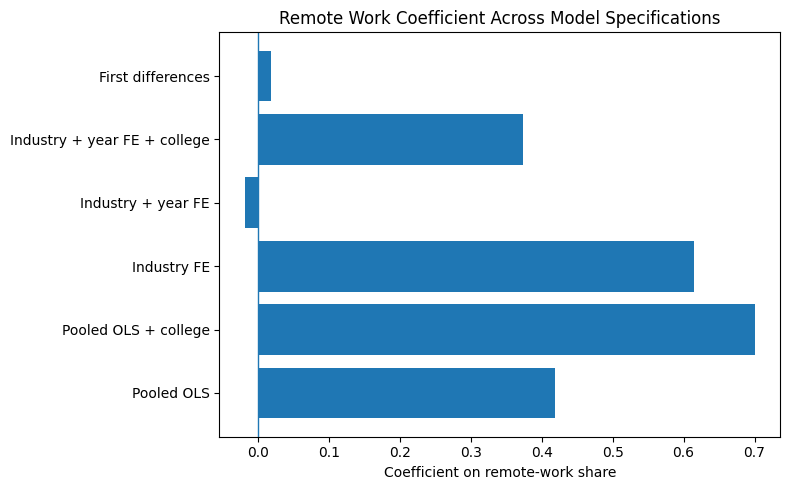

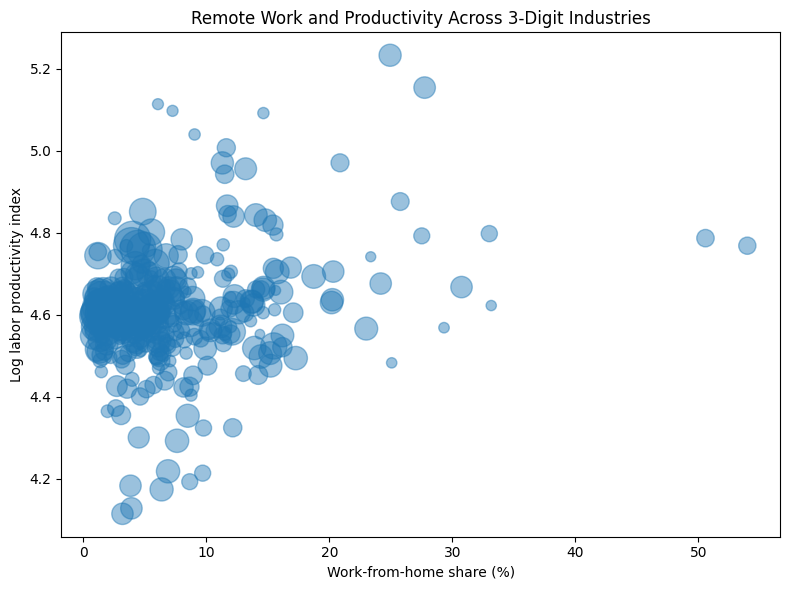


Saved files:
jrl005_remote_work_productivity_panel.csv
jrl005_panel_regression_summary.csv
jrl005_remote_work_coefficients.png
jrl005_remote_work_productivity_scatter.png


In [14]:
# ============================================================
# JRL #005 Remote Work & Productivity Revisited
# 3-Digit NAICS Panel: ACS 2015–2024 + BLS Productivity
# ============================================================

!pip -q install linearmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

# -----------------------------
# 0. Paths
# -----------------------------

BLS_XLSX = "/content/labor-productivity-detailed-industries.xlsx"

# Assumes ACS is already loaded as `acs`
print("ACS shape:", acs.shape)
print("ACS years:", sorted(acs["year"].unique()))

# -----------------------------
# 1. Build ACS 3-digit industry-year panel
# -----------------------------

acs_small = acs[
    (acs["empstat"] == 1) &
    (acs["age"].between(18, 64)) &
    (acs["indnaics"].notna()) &
    (acs["tranwork"].notna())
].copy()

acs_small["indnaics_str"] = acs_small["indnaics"].astype(str)

acs_small["naics3"] = (
    acs_small["indnaics_str"]
    .str.extract(r"(\d+)")[0]
    .str[:3]
)

acs_small = acs_small[
    acs_small["naics3"].notna() &
    (acs_small["naics3"] != "0")
].copy()

# IPUMS TRANWORK: 80 = worked at home
acs_small["wfh"] = (acs_small["tranwork"] == 80).astype(float)

# EDUC coding in this extract: 10 = BA, 11 = graduate/professional
acs_small["college"] = (acs_small["educ"] >= 10).astype(float)

def wavg(group, var):
    return np.average(group[var], weights=group["perwt"])

acs_panel = (
    acs_small
    .groupby(["naics3", "year"])
    .apply(lambda x: pd.Series({
        "wfh_share": wavg(x, "wfh"),
        "college_share": wavg(x, "college"),
        "workers": x["perwt"].sum(),
        "n_obs": len(x)
    }))
    .reset_index()
)

print("\nACS 3-digit panel:")
print(acs_panel.head())
print("Shape:", acs_panel.shape)
print("Unique ACS industries:", acs_panel["naics3"].nunique())

# -----------------------------
# 2. Build BLS 3-digit productivity panel
# -----------------------------

bls = pd.read_excel(BLS_XLSX, sheet_name="MachineReadable")

prod3 = bls[
    (bls["Measure"] == "Labor productivity") &
    (bls["Units"] == "Index (2017=100)") &
    (bls["Digit"] == "3-Digit")
].copy()

prod3["naics3"] = prod3["NAICS"].astype(str).str.extract(r"(\d+)")[0].str[:3]
prod3["year"] = prod3["Year"].astype(int)
prod3["productivity_index"] = pd.to_numeric(prod3["Value"], errors="coerce")

prod_panel = prod3[[
    "naics3", "year", "Industry", "productivity_index"
]].dropna()

print("\nBLS 3-digit productivity panel:")
print(prod_panel.head())
print("Shape:", prod_panel.shape)
print("Unique BLS industries:", prod_panel["naics3"].nunique())

# -----------------------------
# 3. Merge ACS + BLS
# -----------------------------

panel = acs_panel.merge(
    prod_panel,
    on=["naics3", "year"],
    how="inner"
)

panel = panel.sort_values(["naics3", "year"]).copy()
panel["log_productivity"] = np.log(panel["productivity_index"])

# First differences
panel["prod_growth"] = panel.groupby("naics3")["log_productivity"].diff()
panel["wfh_change"] = panel.groupby("naics3")["wfh_share"].diff()
panel["college_change"] = panel.groupby("naics3")["college_share"].diff()

panel = panel.replace([np.inf, -np.inf], np.nan)

print("\nMerged panel:")
print(panel.head())
print("Shape:", panel.shape)
print("Unique merged industries:", panel["naics3"].nunique())
print("Years in merged panel:")
print(panel["year"].value_counts().sort_index())

# Save raw merged panel
panel.to_csv("jrl005_remote_work_productivity_panel.csv", index=False)

# -----------------------------
# 4. Regression dataset
# -----------------------------

reg = panel.dropna(subset=[
    "log_productivity",
    "wfh_share",
    "college_share",
    "workers"
]).copy()

reg = reg[reg["workers"] > 0].copy()

print("\nRegression sample:")
print("Rows:", len(reg))
print("Industries:", reg["naics3"].nunique())
print("Years:", sorted(reg["year"].unique()))

# -----------------------------
# 5. Main models
# -----------------------------

# Model 1: pooled OLS
m1 = smf.wls(
    "log_productivity ~ wfh_share",
    data=reg,
    weights=reg["workers"]
).fit(cov_type="HC1")

# Model 2: pooled OLS + college
m2 = smf.wls(
    "log_productivity ~ wfh_share + college_share",
    data=reg,
    weights=reg["workers"]
).fit(cov_type="HC1")

# Panel setup
reg_fe = reg.set_index(["naics3", "year"])

# Model 3: industry fixed effects
m3 = PanelOLS.from_formula(
    "log_productivity ~ 1 + wfh_share + EntityEffects",
    data=reg_fe,
    weights=reg_fe["workers"]
).fit(cov_type="clustered", cluster_entity=True)

# Model 4: industry + year fixed effects
m4 = PanelOLS.from_formula(
    "log_productivity ~ 1 + wfh_share + EntityEffects + TimeEffects",
    data=reg_fe,
    weights=reg_fe["workers"]
).fit(cov_type="clustered", cluster_entity=True)

# Model 5: industry + year FE + college share
m5 = PanelOLS.from_formula(
    "log_productivity ~ 1 + wfh_share + college_share + EntityEffects + TimeEffects",
    data=reg_fe,
    weights=reg_fe["workers"],
    drop_absorbed=True
).fit(cov_type="clustered", cluster_entity=True)

# First-difference model
fd = panel.dropna(subset=[
    "prod_growth",
    "wfh_change",
    "college_change",
    "workers"
]).copy()

fd = fd[fd["workers"] > 0].copy()

m6 = smf.wls(
    "prod_growth ~ wfh_change + college_change + C(year)",
    data=fd,
    weights=fd["workers"]
).fit(cov_type="HC1")

# -----------------------------
# 6. Print results
# -----------------------------

print("\n==============================")
print("MODEL 1: Pooled OLS")
print("==============================")
print(m1.summary())

print("\n==============================")
print("MODEL 2: Pooled OLS + College")
print("==============================")
print(m2.summary())

print("\n==============================")
print("MODEL 3: Industry Fixed Effects")
print("==============================")
print(m3.summary)

print("\n==============================")
print("MODEL 4: Industry + Year Fixed Effects")
print("==============================")
print(m4.summary)

print("\n==============================")
print("MODEL 5: Industry + Year FE + College")
print("==============================")
print(m5.summary)

print("\n==============================")
print("MODEL 6: First Differences")
print("==============================")
print(m6.summary())

# -----------------------------
# 7. Compact summary table
# -----------------------------

summary = pd.DataFrame({
    "model": [
        "Pooled OLS",
        "Pooled OLS + college",
        "Industry FE",
        "Industry + year FE",
        "Industry + year FE + college",
        "First differences"
    ],
    "wfh_variable": [
        "wfh_share",
        "wfh_share",
        "wfh_share",
        "wfh_share",
        "wfh_share",
        "wfh_change"
    ],
    "wfh_coef": [
        m1.params.get("wfh_share"),
        m2.params.get("wfh_share"),
        m3.params.get("wfh_share"),
        m4.params.get("wfh_share"),
        m5.params.get("wfh_share"),
        m6.params.get("wfh_change")
    ],
    "wfh_pvalue": [
        m1.pvalues.get("wfh_share"),
        m2.pvalues.get("wfh_share"),
        m3.pvalues.get("wfh_share"),
        m4.pvalues.get("wfh_share"),
        m5.pvalues.get("wfh_share"),
        m6.pvalues.get("wfh_change")
    ],
    "college_coef": [
        np.nan,
        m2.params.get("college_share"),
        np.nan,
        np.nan,
        m5.params.get("college_share"),
        m6.params.get("college_change")
    ],
    "college_pvalue": [
        np.nan,
        m2.pvalues.get("college_share"),
        np.nan,
        np.nan,
        m5.pvalues.get("college_share"),
        m6.pvalues.get("college_change")
    ],
    "n_obs": [
        int(m1.nobs),
        int(m2.nobs),
        int(m3.nobs),
        int(m4.nobs),
        int(m5.nobs),
        int(m6.nobs)
    ]
})

print("\n==============================")
print("SUMMARY TABLE")
print("==============================")
print(summary)

summary.to_csv("jrl005_panel_regression_summary.csv", index=False)

# -----------------------------
# 8. Main chart: coefficient comparison
# -----------------------------

coef_plot = summary.dropna(subset=["wfh_coef"]).copy()

plt.figure(figsize=(8,5))
plt.barh(coef_plot["model"], coef_plot["wfh_coef"])
plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient on remote-work share")
plt.title("Remote Work Coefficient Across Model Specifications")
plt.tight_layout()
plt.savefig("jrl005_remote_work_coefficients.png", dpi=300)
plt.show()

# -----------------------------
# 9. Optional scatter: raw relationship
# -----------------------------

plt.figure(figsize=(8,6))

sizes = np.sqrt(reg["workers"] / reg["workers"].max()) * 700

plt.scatter(
    reg["wfh_share"] * 100,
    reg["log_productivity"],
    s=sizes,
    alpha=0.45
)

plt.xlabel("Work-from-home share (%)")
plt.ylabel("Log labor productivity index")
plt.title("Remote Work and Productivity Across 3-Digit Industries")
plt.tight_layout()
plt.savefig("jrl005_remote_work_productivity_scatter.png", dpi=300)
plt.show()

print("\nSaved files:")
print("jrl005_remote_work_productivity_panel.csv")
print("jrl005_panel_regression_summary.csv")
print("jrl005_remote_work_coefficients.png")
print("jrl005_remote_work_productivity_scatter.png")